In [27]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [25]:
import yfinance as yf
import datetime

data = yf.download("MSFT", start='2015-01-01', end='2025-01-01', interval='1h')['Close']

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MSFT']: YFPricesMissingError('possibly delisted; no price data found  (1h 2015-01-01 -> 2025-01-01) (Yahoo error = "1h data not available for startTime=1420088400 and endTime=1735707600. The requested range must be within the last 730 days.")')


In [1]:
invest_api_key = input("Enter Invest API Key: ")

In [3]:
from TInvestDataProvider import TInvestDataProvider
from datetime import timedelta
import pytz
from datetime import datetime
from externalClients.TInvestApi.proto.marketdata_pb2 import (
    CandleInterval
)
import pandas as pd


if invest_api_key is None:
    raise Exception("Invest API Key is missing")

moscow_tz = pytz.timezone('Europe/Moscow')
naive_datetime = datetime(year=2025, month=4, day=24, hour=11, second=1)
moscow_datetime = moscow_tz.localize(naive_datetime)
train_period_end = moscow_datetime.astimezone(pytz.UTC)

data_provider = TInvestDataProvider(invest_api_key)

import asyncio

provider = TInvestDataProvider(api_key=invest_api_key)
TARGET_CANDLE_COUNT = 50_000
RATE_LIMITER_DELAY = 0.25   # Can go as low as 0.2
timestep = timedelta(hours=40)

df = None

try:
    current_end = train_period_end
    step_count = 1
    while True:
        print(f"Step {step_count}. ", end="")
        step_count += 1
        current_start = current_end - timestep

        new_df = await provider.get_historical_candles(
            instrument_id="e6123145-9665-43e0-8413-cd61b8aa9b13",
            from_time=current_start,
            to_time=current_end,
            interval=CandleInterval.CANDLE_INTERVAL_1_MIN
        )

        if df is None:
            df = new_df
        else:
            df = pd.concat([new_df, df])

        if len(df) >= TARGET_CANDLE_COUNT:
            df = df.iloc[-TARGET_CANDLE_COUNT:]
            print(f"Current df shape: {df.shape}")
            break

        current_end = current_start
        print(f"Current df shape: {df.shape}; new candles fetched = {new_df.shape[0]}")
        await asyncio.sleep(RATE_LIMITER_DELAY)
except Exception as e:
    print(f"Unable to fetch data {e}")
    last_request_sent = {
        "instrument_id": "e6123145-9665-43e0-8413-cd61b8aa9b13",
        "from_time": current_start,
        "to_time": current_end,
        "interval": CandleInterval.CANDLE_INTERVAL_1_MIN
    }
    print(f"Last executed request: {last_request_sent}")
finally:
    await provider.close()

Step 1. Current df shape: (1520, 7); new candles fetched = 1520
Step 2. 

C:\Users\Kirill\AppData\Local\Temp\ipykernel_43968\1778349289.py:57: RuntimeWarning: coroutine 'sleep' was never awaited
  asyncio.sleep(RATE_LIMITER_DELAY)


Current df shape: (3218, 7); new candles fetched = 1698
Step 3. Current df shape: (4966, 7); new candles fetched = 1748
Step 4. Current df shape: (6545, 7); new candles fetched = 1579
Step 5. Current df shape: (8243, 7); new candles fetched = 1698
Step 6. Current df shape: (9986, 7); new candles fetched = 1743
Step 7. Current df shape: (11535, 7); new candles fetched = 1549
Step 8. Current df shape: (13395, 7); new candles fetched = 1860
Step 9. Current df shape: (15138, 7); new candles fetched = 1743
Step 10. Current df shape: (16658, 7); new candles fetched = 1520
Step 11. Current df shape: (18473, 7); new candles fetched = 1815
Step 12. Current df shape: (20485, 7); new candles fetched = 2012
Step 13. Current df shape: (22005, 7); new candles fetched = 1520
Step 14. Current df shape: (23703, 7); new candles fetched = 1698
Step 15. Current df shape: (25459, 7); new candles fetched = 1756
Step 16. Current df shape: (27219, 7); new candles fetched = 1760
Step 17. Current df shape: (289

In [17]:
df.head()

data = df['close'].to_numpy()

In [18]:
import numpy as np

class Normalizer():
    def __init__(self):
        self.min = None
        self.max = None

    def fit_transform(self, x):
        self.min = np.min(x, axis=0)#, keepdims=True)
        self.max = np.max(x, axis=0)#, keepdims=True)
        normalized_x = 2 * (x - self.min) / (self.max - self.min) - 1
        return normalized_x

    def transform(self, x):
        normalized_x = 2 * (x - self.min) / (self.max - self.min) - 1
        return normalized_x

    def inverse_transform(self, x):
        original_x = (x + 1) / 2 * (self.max - self.min) + self.min
        return original_x

# normalize
scaler = Normalizer()
normalized_data = scaler.fit_transform(data)

In [19]:
import torch
import torch.nn as nn

class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_layer_size, output_size)

        # Good initialization
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Take output of last time step
        out = self.fc(out)
        return out.view(-1)  # Flatten

In [20]:
import pandas as pd

normalized_df = pd.DataFrame(data=normalized_data, columns=['Close'])
normalized_df.head()

,Close
0,0.502879
1,0.500279
2,0.499536
3,0.499536
4,0.492476


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def denormalize(predictions, scaler):
    """Convert normalized predictions back to original price scale"""
    return scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()


def evaluate_model(model, loader, scaler, device):
    model.eval()
    all_preds = []
    all_targets = []
    test_losses = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            test_losses.append(loss.item())

            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    # Concatenate all batches
    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    # Denormalize for meaningful metrics
    original_preds = denormalize(preds, scaler)
    original_targets = denormalize(targets, scaler)

    # Calculate metrics
    metrics = {
        'test_loss': np.mean(test_losses),
        'mae': mean_absolute_error(original_targets, original_preds),
        'rmse': np.sqrt(mean_squared_error(original_targets, original_preds)),
        'r2': r2_score(original_targets, original_preds),
        'direction_accuracy': (np.sign(original_preds[1:] - original_targets[:-1]) ==
                              np.sign(original_targets[1:] - original_targets[:-1])).mean()
    }
    return metrics

In [ ]:
SEQ_LENGTH = 16
BATCH_SIZE = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 20

# Dataset
class YourDataset(Dataset):
    def __init__(self, df, seq_length=16):
        self.data = torch.tensor(df['Close'].values, dtype=torch.float32)
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length].unsqueeze(-1)  # (seq_len, 1)
        y = self.data[idx+self.seq_length]
        return x, y

dataset = YourDataset(normalized_df, seq_length=SEQ_LENGTH)


In [ ]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_layer_size, output_size)

        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.view(-1)

model = SimpleLSTM(input_size=1, hidden_layer_size=32, num_layers=1, output_size=1).to(DEVICE)

In [34]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [36]:
def train(model, epochs):
    best_val_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        avg_loss = np.mean(train_losses)
        print(f"Epoch {epoch+1}/{EPOCHS} --> Train Loss: {avg_loss:.6f}")

        val_metrics = evaluate_model(model, test_loader, scaler, DEVICE)

        # Print statistics
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"Train Loss: {np.mean(train_losses):.6f}")
        print("Validation Metrics:")
        print(f"- Loss: {val_metrics['test_loss']:.6f}")
        print(f"- MAE: ${val_metrics['mae']:.4f}")
        print(f"- RMSE: ${val_metrics['rmse']:.4f}")
        print(f"- R²: {val_metrics['r2']:.4f}")
        print(f"- Direction Accuracy: {val_metrics['direction_accuracy']:.2%}")

        # Save best model
        if val_metrics['test_loss'] < best_val_loss:
            best_val_loss = val_metrics['test_loss']
            torch.save(model.state_dict(), 'best_lstm.pth')
            print("Saved new best model!")


In [37]:
train(model, epochs=20)

Epoch 1/20 --> Train Loss: 0.000088

Epoch 1/20
Train Loss: 0.000088
Validation Metrics:
- Loss: 0.000068
- MAE: $0.1446
- RMSE: $0.2226
- R²: 0.9997
- Direction Accuracy: 99.52%
Saved new best model!
Epoch 2/20 --> Train Loss: 0.000084

Epoch 2/20
Train Loss: 0.000084
Validation Metrics:
- Loss: 0.000097
- MAE: $0.2034
- RMSE: $0.2654
- R²: 0.9995
- Direction Accuracy: 99.25%
Epoch 3/20 --> Train Loss: 0.000083

Epoch 3/20
Train Loss: 0.000083
Validation Metrics:
- Loss: 0.000089
- MAE: $0.1819
- RMSE: $0.2542
- R²: 0.9996
- Direction Accuracy: 99.39%
Epoch 4/20 --> Train Loss: 0.000082

Epoch 4/20
Train Loss: 0.000082
Validation Metrics:
- Loss: 0.000080
- MAE: $0.1666
- RMSE: $0.2400
- R²: 0.9996
- Direction Accuracy: 99.51%
Epoch 5/20 --> Train Loss: 0.000082

Epoch 5/20
Train Loss: 0.000082
Validation Metrics:
- Loss: 0.000066
- MAE: $0.1299
- RMSE: $0.2190
- R²: 0.9997
- Direction Accuracy: 99.61%
Saved new best model!
Epoch 6/20 --> Train Loss: 0.000081

Epoch 6/20
Train Loss: 0

In [30]:
model.eval()
predictions = []
true_values = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb)
        predictions.append(preds.cpu())
        true_values.append(yb.cpu())

# 4. stack predictions and true values
predictions = torch.cat(predictions, dim=0)
true_values = torch.cat(true_values, dim=0)

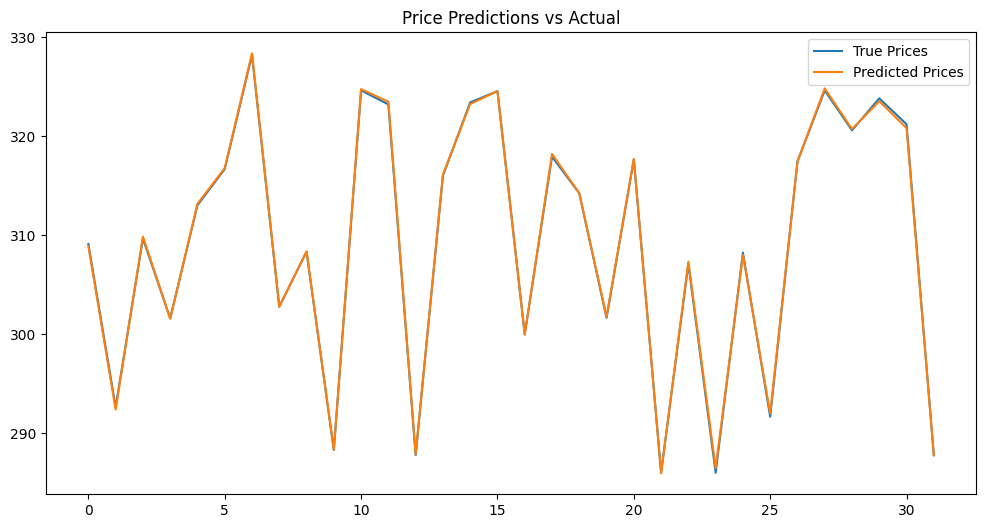

In [38]:
def plot_predictions(model, loader, scaler, device, n_samples=100):
    model.eval()
    with torch.no_grad():
        xb, yb = next(iter(loader))
        preds = model(xb.to(device)).cpu().numpy()

    true_prices = denormalize(yb.numpy(), scaler)
    pred_prices = denormalize(preds, scaler)

    plt.figure(figsize=(12,6))
    plt.plot(true_prices[:n_samples], label='True Prices')
    plt.plot(pred_prices[:n_samples], label='Predicted Prices')
    plt.title("Price Predictions vs Actual")
    plt.legend()
    plt.show()

# Call after training
plot_predictions(model, test_loader, scaler, DEVICE)

In [58]:
xb, yb = next(iter(test_loader))
preds = model(xb.to(device)).cpu().detach().numpy()

true_prices = denormalize(yb.numpy(), scaler)
pred_prices = denormalize(preds, scaler)

print(true_prices)
print(pred_prices)

[309.1     292.63    309.66    301.59    313.02002 316.67    328.21
 302.77    308.33002 288.31    324.61002 323.2     287.79    316.
 323.4     324.54    299.98    317.92    314.23    301.65    317.65
 286.      307.1     286.      308.23    291.67    317.44    324.61002
 320.58002 323.81    321.19    287.77   ]
[308.8669  292.38785 309.85248 301.56207 313.16486 316.76938 328.3614
 302.76828 308.35443 288.32672 324.74353 323.46793 287.8485  316.1061
 323.24268 324.54642 299.95227 318.20084 314.2301  301.7541  317.68408
 285.95294 307.33218 286.46066 307.99942 292.0046  317.41733 324.81482
 320.7032  323.5251  320.7997  287.78458]


In [59]:
xb

tensor([[[ 0.2045],
         [ 0.2019],
         [ 0.2053],
         [ 0.2097],
         [ 0.2205],
         [ 0.2213],
         [ 0.2187],
         [ 0.2134],
         [ 0.2172],
         [ 0.2172],
         [ 0.2209],
         [ 0.2224],
         [ 0.2343],
         [ 0.2406],
         [ 0.2298],
         [ 0.2213]],

        [[-0.4260],
         [-0.4297],
         [-0.4185],
         [-0.4204],
         [-0.4182],
         [-0.4044],
         [-0.4178],
         [-0.4119],
         [-0.4119],
         [-0.4093],
         [-0.4074],
         [-0.4107],
         [-0.4052],
         [-0.3944],
         [-0.3948],
         [-0.3884]],

        [[ 0.2655],
         [ 0.2662],
         [ 0.2647],
         [ 0.2655],
         [ 0.2655],
         [ 0.2673],
         [ 0.2673],
         [ 0.2684],
         [ 0.2677],
         [ 0.2677],
         [ 0.2670],
         [ 0.2684],
         [ 0.2640],
         [ 0.2617],
         [ 0.2610],
         [ 0.2599]],

        [[-0.0440],
         [-0.0

In [124]:
def simulate_trading(
        model,
        data,
        scaler,
        device,
        initial_balance=10000,
        commission=0.0005,
        lookback=16,
        buy_signal = 0.001,
        sell_signal = 0.003
):
    """
    Simulates trading with minute-by-minute decision making and visualizes trades

    Args:
        model: Trained PyTorch model
        data: 1D numpy array of raw close prices (1-minute intervals)
        scaler: Normalizer instance used for scaling
        device: 'cuda' or 'cpu'
        initial_balance: Starting cash balance
        commission: Trading commission per trade (default 0.05%)
        lookback: Number of past minutes needed for prediction
    """
    model.eval()

    # Track portfolio state
    balance = initial_balance
    shares_owned = 0  # Always >= 0 (no short selling)
    current_price = 0

    # Track history for plotting
    balance_history = [balance]
    total_value_history = [balance]
    price_history = []
    buy_signals = []
    sell_signals = []

    # Convert raw data to normalized
    normalized_data = scaler.transform(data.reshape(-1, 1)).flatten()

    for i in range(lookback, len(data)-1):
        current_price = data[i]
        price_history.append(current_price)

        # Prepare input sequence
        seq = normalized_data[i-lookback:i].reshape(1, lookback, 1)
        seq = torch.FloatTensor(seq).to(device)

        # Make prediction
        with torch.no_grad():
            pred = model(seq).cpu().numpy()[0]
            pred_price = scaler.inverse_transform(np.array([[pred]]))[0][0]

        # Calculate expected return
        expected_return = (pred_price - current_price) / current_price

        # Trading decision logic - SIMPLIFIED VERSION
        if expected_return > buy_signal:  # Strong buy signal
            if shares_owned == 0:    # Only buy if we don't own shares
                # Calculate how many shares we can buy
                max_shares = (balance * (1 - commission)) / current_price
                shares_owned = max_shares
                balance = 0
                buy_signals.append((i-lookback, current_price))

        elif expected_return < -sell_signal:  # Sell signal
            if shares_owned > 0:      # Only sell if we own shares
                # Sell all shares
                sale_value = shares_owned * current_price * (1 - commission)
                balance += sale_value
                shares_owned = 0
                sell_signals.append((i-lookback, current_price))

        # Calculate current portfolio value
        position_value = shares_owned * current_price
        total_value = balance + position_value

        # Record history
        balance_history.append(balance)
        total_value_history.append(total_value)

    # Final portfolio value (sell any remaining shares)
    if shares_owned > 0:
        final_value = balance + (shares_owned * data[-1] * (1 - commission))
    else:
        final_value = balance

    returns = (final_value - initial_balance) / initial_balance

    # Calculate metrics
    returns_series = np.array(total_value_history) / initial_balance - 1
    std_dev = np.std(returns_series)
    sharpe_ratio = np.mean(returns_series) / std_dev * np.sqrt(252*24*60) if std_dev > 0 else 0

    # Create figure with 2 subplots
    #plt.figure(figsize=(14, 10))

    # Plot 1: Price with buy/sell signals
    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(price_history, label='Price', color='blue', alpha=0.7)

    # Plot buy/sell signals
    if buy_signals:
        buy_x, buy_y = zip(*buy_signals)
        ax1.scatter(buy_x, buy_y, color='green', marker='^', s=100, label='Buy', alpha=0.8)

    if sell_signals:
        sell_x, sell_y = zip(*sell_signals)
        ax1.scatter(sell_x, sell_y, color='red', marker='v', s=100, label='Sell', alpha=0.8)

    ax1.set_title('Price with Buy/Sell Signals')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Portfolio value
    ax2 = plt.subplot(2, 1, 2)
    ax2.plot(total_value_history, label='Total Portfolio Value', color='purple')
    ax2.plot(balance_history, label='Cash Balance', color='orange', linestyle='--')

    # Mark buy/sell points on value plot using the same indices
    if buy_signals:
        buy_x, _ = zip(*buy_signals)
        buy_values = [total_value_history[x] for x in buy_x]
        ax2.scatter(buy_x, buy_values, color='green', marker='^', s=100, alpha=0.8)

    if sell_signals:
        sell_x, _ = zip(*sell_signals)
        sell_values = [total_value_history[x] for x in sell_x]
        ax2.scatter(sell_x, sell_values, color='red', marker='v', s=100, alpha=0.8)

    ax2.set_title(f'Portfolio Value (Final: ${final_value:,.2f}, Return: {returns:.2%})')
    ax2.set_xlabel('Minutes')
    ax2.set_ylabel('Value ($)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n=== Trading Simulation Results ===")
    print(f"Initial Balance: ${initial_balance:,.2f}")
    print(f"Final Value: ${final_value:,.2f}")
    print(f"Total Return: {returns:.2%}")
    print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Total Trades: {len(buy_signals) + len(sell_signals)}")
    return returns
    #print(f"Commission Paid: ${initial_balance - final_value + (final_value - initial_balance - (shares * data[-1] - shares * current_price)):,.2f}")

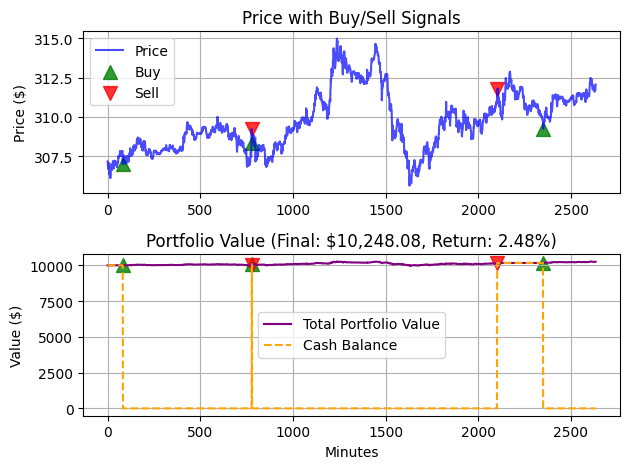


=== Trading Simulation Results ===
Initial Balance: $10,000.00
Final Value: $10,248.08
Total Return: 2.48%
Annualized Sharpe Ratio: 837.11
Total Trades: 5


0.02480841722966052

In [125]:
ONE_DAY_TRADING_OFFSET = -(8 * 60 + 50)


days = 5


simulate_trading(
    model,
    data[(days * ONE_DAY_TRADING_OFFSET):],
    scaler,
    device,
    10000,
    commission=0.0005,
    buy_signal=0.0017,
    sell_signal=0.0026
)

In [128]:
def simulate_trading(
        model,
        data,
        scaler,
        device,
        initial_balance=10000,
        commission=0.0005,
        lookback=16,
        buy_signal = 0.001,
        sell_signal = 0.003
):
    model.eval()

    balance = initial_balance
    shares_owned = 0

    balance_history = [balance]
    total_value_history = [balance]
    price_history = []
    buy_signals = []
    sell_signals = []

    # Convert raw data to normalized
    normalized_data = scaler.transform(data.reshape(-1, 1)).flatten()

    for i in range(lookback, len(data)-1):
        current_price = data[i]
        price_history.append(current_price)

        seq = normalized_data[i-lookback:i].reshape(1, lookback, 1)
        seq = torch.FloatTensor(seq).to(device)

        with torch.no_grad():
            pred = model(seq).cpu().numpy()[0]
            pred_price = scaler.inverse_transform(np.array([[pred]]))[0][0]

        expected_return = (pred_price - current_price) / current_price

        if expected_return > buy_signal:
            if shares_owned == 0:
                max_shares = (balance * (1 - commission)) / current_price
                shares_owned = max_shares
                balance = 0
                buy_signals.append((i-lookback, current_price))

        elif expected_return < -sell_signal:
            if shares_owned > 0:
                sale_value = shares_owned * current_price * (1 - commission)
                balance += sale_value
                shares_owned = 0
                sell_signals.append((i-lookback, current_price))

        position_value = shares_owned * current_price
        total_value = balance + position_value

        balance_history.append(balance)
        total_value_history.append(total_value)

    if shares_owned > 0:
        final_value = balance + (shares_owned * data[-1] * (1 - commission))
    else:
        final_value = balance

    returns = (final_value - initial_balance) / initial_balance

    # Calculate metrics
    returns_series = np.array(total_value_history) / initial_balance - 1
    std_dev = np.std(returns_series)

    if buy_signals:
        buy_x, _ = zip(*buy_signals)
    if sell_signals:
        sell_x, _ = zip(*sell_signals)

    return returns

In [ ]:
from itertools import product

def grid_search_trading_params(model, data, scaler, device, initial_balance=10000):
    """
    Grid search for optimal buy/sell signal thresholds

    Returns:
        DataFrame with results for all parameter combinations
    """
    buy_thresholds = np.linspace(0.0001, 0.005, 100)  # 0.01% to 0.5%
    sell_thresholds = np.linspace(0.0001, 0.03, 100)   # 0.05% to 1%

    results = []

    for buy_signal, sell_signal in product(buy_thresholds, sell_thresholds):
        if sell_signal <= buy_signal:
            continue

        try:
            returns = simulate_trading(
                model=model,
                data=data,
                scaler=scaler,
                device=device,
                initial_balance=initial_balance,
                commission=0.0005,
                buy_signal=buy_signal,
                sell_signal=sell_signal
            )

            returns_pct = returns * 100  # Convert to percentage

            results.append({
                'buy_signal': buy_signal,
                'sell_signal': sell_signal,
                'returns_pct': returns_pct,
                'signal_ratio': sell_signal / buy_signal
            })

        except Exception as e:
            print(f"Failed for buy={buy_signal:.4f}, sell={sell_signal:.4f}: {str(e)}")

    # Convert to DataFrame and find best parameters
    results_df = pd.DataFrame(results)
    if not results_df.empty:
        best = results_df.loc[results_df['returns_pct'].idxmax()]
        print(f"\nBest parameters: buy={best['buy_signal']:.4f}, sell={best['sell_signal']:.4f}")
        print(f"Expected return: {best['returns_pct']:.2f}%")

    return results_df

# Usage:
results = grid_search_trading_params(
    model=model,
    data=data[(days * ONE_DAY_TRADING_OFFSET):],
    scaler=scaler,
    device=device
)

import seaborn as sns
import matplotlib.pyplot as plt

# Visualize results
if not results.empty:
    plt.figure(figsize=(12, 8))

    # Create pivot table with correct syntax
    pivot_df = results.pivot_table(
        values='returns_pct',
        index='buy_signal',
        columns='sell_signal'
    )

    sns.heatmap(
        data=pivot_df,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",
        cbar_kws={'label': 'Returns (%)'}
    )
    plt.title("Returns by Buy/Sell Thresholds")
    plt.xlabel("Sell Signal Threshold")
    plt.ylabel("Buy Signal Threshold")
    plt.tight_layout()
    plt.show()
else:
    print("No valid results to plot")

In [31]:
if predictions.ndim == 1:
    predictions = predictions.unsqueeze(-1)

if true_values.ndim == 1:
    true_values = true_values.unsqueeze(-1)

predictions_rescaled = scaler.inverse_transform(predictions.numpy())
true_values_rescaled = scaler.inverse_transform(true_values.numpy())

predictions_rescaled = predictions_rescaled.flatten()
true_values_rescaled = true_values_rescaled.flatten()

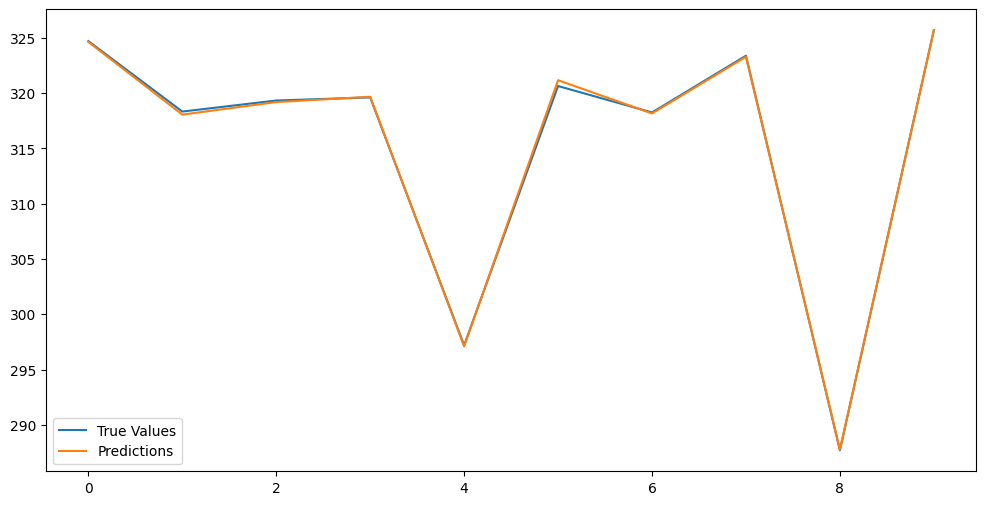

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(true_values_rescaled[-10:], label="True Values")
plt.plot(predictions_rescaled[-10:], label="Predictions")
plt.legend()
plt.show()

In [33]:


def evaluate_model(model, loader, scaler, device):
    model.eval()
    all_preds = []
    all_targets = []
    test_losses = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            test_losses.append(loss.item())

            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    # Concatenate all batches
    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    # Denormalize for meaningful metrics
    original_preds = denormalize(preds, scaler)
    original_targets = denormalize(targets, scaler)

    # Calculate metrics
    metrics = {
        'test_loss': np.mean(test_losses),
        'mae': mean_absolute_error(original_targets, original_preds),
        'rmse': np.sqrt(mean_squared_error(original_targets, original_preds)),
        'r2': r2_score(original_targets, original_preds),
        'direction_accuracy': (np.sign(original_preds[1:] - original_targets[:-1]) ==
                              np.sign(original_targets[1:] - original_targets[:-1])).mean()
    }
    return metrics

# Modified training loop with validation
best_val_loss = float('inf')
for epoch in range(EPOCHS):
    # Training phase (unchanged)
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        # ... existing training code ...
        train_losses.append(loss.item())

    # Validation phase
    val_metrics = evaluate_model(model, test_loader, scaler, DEVICE)

    # Print statistics
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {np.mean(train_losses):.6f}")
    print("Validation Metrics:")
    print(f"- Loss: {val_metrics['test_loss']:.6f}")
    print(f"- MAE: ${val_metrics['mae']:.4f}")
    print(f"- RMSE: ${val_metrics['rmse']:.4f}")
    print(f"- R²: {val_metrics['r2']:.4f}")
    print(f"- Direction Accuracy: {val_metrics['direction_accuracy']:.2%}")

    # Save best model
    if val_metrics['test_loss'] < best_val_loss:
        best_val_loss = val_metrics['test_loss']
        torch.save(model.state_dict(), 'best_lstm.pth')
        print("Saved new best model!")


Epoch 1/20
Train Loss: 0.000059
Validation Metrics:
- Loss: 0.000074
- MAE: $0.1480
- RMSE: $0.2320
- R²: 0.9996
- Direction Accuracy: 99.50%
Saved new best model!

Epoch 2/20
Train Loss: 0.000059
Validation Metrics:
- Loss: 0.000074
- MAE: $0.1480
- RMSE: $0.2320
- R²: 0.9996
- Direction Accuracy: 99.50%

Epoch 3/20
Train Loss: 0.000059
Validation Metrics:
- Loss: 0.000074
- MAE: $0.1480
- RMSE: $0.2320
- R²: 0.9996
- Direction Accuracy: 99.50%

Epoch 4/20
Train Loss: 0.000059
Validation Metrics:
- Loss: 0.000074
- MAE: $0.1480
- RMSE: $0.2320
- R²: 0.9996
- Direction Accuracy: 99.50%

Epoch 5/20
Train Loss: 0.000059
Validation Metrics:
- Loss: 0.000074
- MAE: $0.1480
- RMSE: $0.2320
- R²: 0.9996
- Direction Accuracy: 99.50%

Epoch 6/20
Train Loss: 0.000059
Validation Metrics:
- Loss: 0.000074
- MAE: $0.1480
- RMSE: $0.2320
- R²: 0.9996
- Direction Accuracy: 99.50%

Epoch 7/20
Train Loss: 0.000059
Validation Metrics:
- Loss: 0.000074
- MAE: $0.1480
- RMSE: $0.2320
- R²: 0.9996
- Dire

In [63]:
type(data)


numpy.ndarray